<a href="https://colab.research.google.com/github/Hibashanti/Adult-Income-Dataset/blob/main/%D9%90Adult_Income_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Adult_Income_Dataset

- Author : Hiba Shanti



### Project overview
 -1- Import Libraries and Load the Data



In [70]:
# Import packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder,LabelEncoder
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,ConfusionMatrixDisplay, recall_score,precision_score, classification_report
from imblearn.pipeline import make_pipeline as make_sampler_pipeline
from sklearn.inspection import permutation_importance
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectFromModel
from imblearn.over_sampling import SMOTE,SMOTENC
from sklearn.linear_model import LogisticRegression
from sklearn.inspection import permutation_importance
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import metrics
from tensorflow.keras.metrics import Precision, Recall


In [4]:
# Mount to Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
path="/content/drive/MyDrive/Axsos Academy/AXSOSACADEMY-1/05-IntermediateML/Week18/Data/adult.csv"
df=pd.read_csv(path)
df.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48842 non-null  int64 
 1   workclass        48842 non-null  object
 2   fnlwgt           48842 non-null  int64 
 3   education        48842 non-null  object
 4   educational-num  48842 non-null  int64 
 5   marital-status   48842 non-null  object
 6   occupation       48842 non-null  object
 7   relationship     48842 non-null  object
 8   race             48842 non-null  object
 9   gender           48842 non-null  object
 10  capital-gain     48842 non-null  int64 
 11  capital-loss     48842 non-null  int64 
 12  hours-per-week   48842 non-null  int64 
 13  native-country   48842 non-null  object
 14  income           48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


#### What is the target?
 - Income
#### What does one row represent?
 - individual’s personal information.
#### How many features does the data have
 - 15 features
#### How many rows are in the dataset?
 - 48,841



### Data Exploration / Data Cleaning

In [7]:
# fnlwgt colun represents how many people in the real population this individual represents.
df=df.drop('fnlwgt',axis=1)

In [8]:
# Check for duplications
df.duplicated().sum()

np.int64(6374)

In [9]:
# remove duplications
df.drop_duplicates(inplace=True)
# Confirm
df.duplicated().sum()

np.int64(0)

In [10]:
#check for missing values
df.isna().sum().sum()

np.int64(0)

In [11]:
# Check inconsistances in categorical columns
categorical_col=df.select_dtypes(include='object').columns
for col in categorical_col:
  print(col)
  print(df[col].value_counts())

workclass
workclass
Private             28312
Self-emp-not-inc     3735
Local-gov            3011
?                    2411
State-gov            1927
Self-emp-inc         1644
Federal-gov          1397
Without-pay            21
Never-worked           10
Name: count, dtype: int64
education
education
HS-grad         12919
Some-college     9188
Bachelors        6967
Masters          2499
Assoc-voc        1961
11th             1598
Assoc-acdm       1563
10th             1277
7th-8th           931
Prof-school       813
9th               737
12th              618
Doctorate         576
5th-6th           498
1st-4th           242
Preschool          81
Name: count, dtype: int64
marital-status
marital-status
Married-civ-spouse       19215
Never-married            13360
Divorced                  6218
Separated                 1512
Widowed                   1499
Married-spouse-absent      627
Married-AF-spouse           37
Name: count, dtype: int64
occupation
occupation
Prof-specialty       5679
E

In [12]:
# Replace the "?" value to nan
df.replace('?', np.nan, inplace=True)

In [13]:
# Check inconsistances in numerical value
numerical_col=df.select_dtypes('number').columns
numerical_col

Index(['age', 'educational-num', 'capital-gain', 'capital-loss',
       'hours-per-week'],
      dtype='object')

In [14]:
df.describe()

,age,educational-num,capital-gain,capital-loss,hours-per-week
count,42468.000000,42468.000000,42468.000000,42468.000000,42468.000000
mean,39.476947,10.094801,1226.217128,99.859212,40.650702
std,13.779595,2.658658,7931.500736,429.072095,12.867960
min,17.000000,1.000000,0.000000,0.000000,1.000000
25%,29.000000,9.000000,0.000000,0.000000,38.000000
50%,38.000000,10.000000,0.000000,0.000000,40.000000
75%,49.000000,13.000000,0.000000,0.000000,45.000000
max,90.000000,16.000000,99999.000000,4356.000000,99.000000


### Exploratory Visualizations

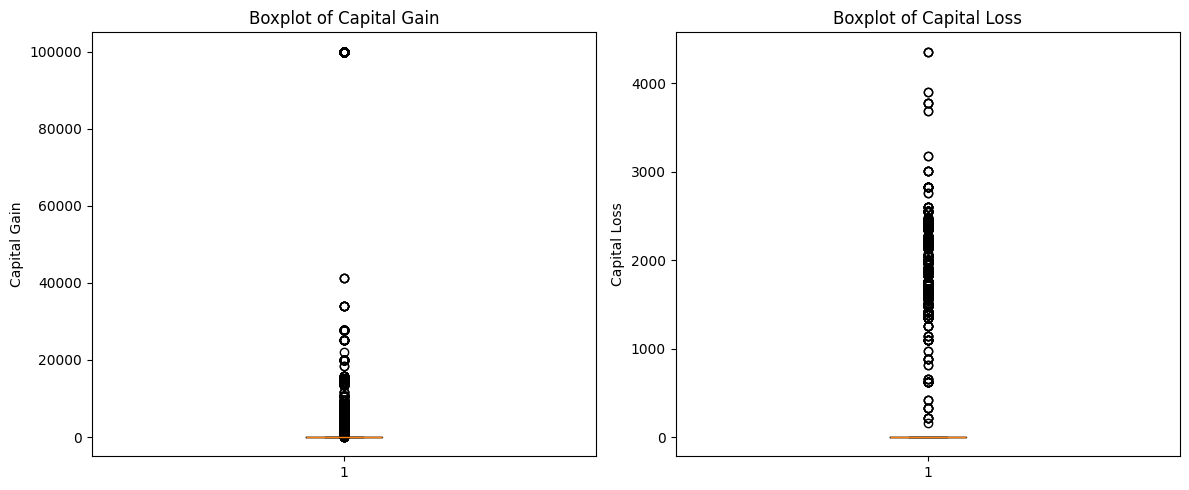

In [15]:
# Visualizing the capital gain and capital loss columns seperatly.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Capital Gain
axes[0].boxplot(df['capital-gain'])
axes[0].set_title('Boxplot of Capital Gain')
axes[0].set_ylabel('Capital Gain')

# Capital Loss
axes[1].boxplot(df['capital-loss'])
axes[1].set_title('Boxplot of Capital Loss')
axes[1].set_ylabel('Capital Loss')

plt.tight_layout()
plt.show()

#Because most values are 0, The boxplot look compressed at the bottom with many extreme outliers.
# This indicates a highly skewed features

In [16]:
def plot_categorical_vs_target(df, x, y, fillna=True, figsize=(6,4),place="MISSING", order=None, target_type="reg" ) :
# make a copy of the df
 df_copy =df.copy()
#fill with placeholder
 if fillna == True :
  df_copy[x]=df_copy[x].fillna(place)
 else :
#drop null
  df_copy=df_copy.dropna(subset=[x])
#plot the graph
 fig,ax=plt.subplots(figsize=figsize)
# REGRESSION-TARGET PLOT
 if target_type == "reg" :
 # stripplot customizing
  sns.stripplot(data=df_copy, x=x, y=y, hue=x, ax=ax,order=order, legend=False, edgecolor="White", linewidth=0.5, size=3, zorder=0)
# Bar plot customizing
  sns.barplot(data=df_copy, x=x, y=y, ax=ax, alpha=0.6, order= order, linewidth=1, edgecolor="black", errorbar=None)
 elif target_type=='class':
  ax = sns.histplot(data=df_copy, hue=y, x=x, stat='percent',  multiple='fill')
 ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
 ax.set_title(f"{x} vs. {y}")
 fig.tight_layout()
 return fig, ax;

/tmp/ipykernel_270/1969441068.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


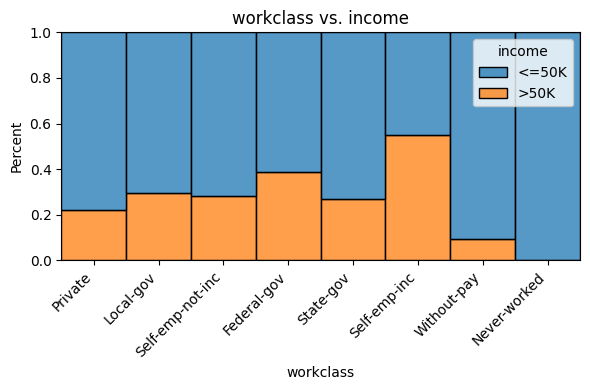

In [17]:
plot_categorical_vs_target(df, x="workclass", y="income", fillna=False, figsize=(6,4),place="MISSING", order=None, target_type="class" );

#Workclass does influence income
#Being Self-emp-inc strongly increases probability of earning >50K
#Most other categories are dominated by ≤50K

### Preprocessing Step


In [18]:
# Split the data
y=df['income']
X=df.drop('income',axis=1)
X_train,X_test, y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)


In [19]:
# Chaek the balance
y_train.value_counts(normalize=True)

,proportion
income,
<=50K,0.754665
>50K,0.245335


In [20]:
# Define the tuple for categorical columns
cat_col=X_train.select_dtypes(include='object').columns
#impute missing values
cat_imputer=SimpleImputer(strategy="constant", fill_value="MISSING")
# one hot encoding the data
col_ohe=OneHotEncoder(handle_unknown="ignore", sparse_output=False)
# make pipeline
cat_pipeline=make_pipeline(cat_imputer,col_ohe)
# Make a tuple
cat_tuple=("categorical",cat_pipeline,cat_col)

In [21]:
# Define the tuple for numerical columns
num_col=X_train.select_dtypes(include='number').columns
#impute missing values
num_imputer=SimpleImputer(strategy="median")
# scale
num_scaler=StandardScaler()
# make pipeline
num_pipeline=make_pipeline(num_imputer,num_scaler)
# Make a tuple
num_tuple=("numerical",num_pipeline,num_col)

In [22]:
# Make a column transformer
preprocesser=ColumnTransformer([cat_tuple,num_tuple],remainder="passthrough")
preprocesser.fit_transform(X_train)
preprocesser.transform(X_test)


array([[ 0.        ,  0.        ,  0.        , ..., -0.15424727,
        -0.23352597,  0.72878559],
       [ 0.        ,  0.        ,  0.        , ..., -0.15424727,
        -0.23352597,  0.33951544],
       [ 0.        ,  0.        ,  1.        , ..., -0.15424727,
        -0.23352597, -1.21756518],
       ...,
       [ 0.        ,  1.        ,  0.        , ..., -0.15424727,
        -0.23352597, -0.04975472],
       [ 0.        ,  0.        ,  0.        , ...,  0.22506094,
        -0.23352597,  0.72878559],
       [ 0.        ,  0.        ,  0.        , ..., -0.15424727,
        -0.23352597, -0.82829502]])

In [23]:
# Initaite the model
model=RandomForestClassifier(random_state=42)
#Create a pippeline
model_pipe=make_pipeline(preprocesser,model)
# fit and transform the model on training data
model_pipe.fit(X_train,y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('categorical',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(fill_value='MISSING',
                                                                                 strategy='constant')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'gender', 'native-country'],
      dtype='object')),
                                                 ('numerical',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  Index(['age', 'educational-num', 'capital-gain', 'capital-loss',
       'hours-per-week'],
      dtype='object'))])),
                ('randomforestclassifier',
                 RandomForestClassifier(random_state=42))])

In [24]:
def classification_metrics(y_test, y_pred, label='',output_dict=False, figsize=(8,4),normalize='true', cmap='Blues',colorbar=False):
# Get the classification report
 report = classification_report(y_test, y_pred)
 ## Print header and report
 header = "-"*70
 print(header, f" Classification Metrics: {label}", header, sep='\n')
 print(report)
 ## CONFUSION MATRICES SUBPLOTS
 fig, axes = plt.subplots(ncols=2, figsize=figsize)
 # create a confusion matrix  of raw counts
 ConfusionMatrixDisplay.from_predictions(y_test, y_pred,normalize=None, cmap='gist_gray', colorbar=colorbar,ax = axes[0],);
 axes[0].set_title("Raw Counts")
 # create a confusion matrix with the test data
 ConfusionMatrixDisplay.from_predictions(y_test, y_pred,normalize=normalize, cmap=cmap, colorbar=colorbar,ax = axes[1]);
 axes[1].set_title("Normalized Confusion Matrix")
 # Adjust layout and show figure
 fig.tight_layout()
 plt.show()
 # Return dictionary of classification_report
 if output_dict==True:
   report_dict = classification_report(y_test, y_pred, output_dict=True)
   return report_dict
def evaluate_classification(model, X_train, y_train, X_test, y_test,figsize=(6,4), normalize='true', output_dict = False,cmap_train='Blues', cmap_test="Reds",colorbar=False):
 # Get predictions for training data
  y_train_pred = model.predict(X_train)
 # Call the helper function to obtain regression metrics for training data
  results_train = classification_metrics(y_train, y_train_pred, #verbose = verbose,
                                    output_dict=True,figsize=figsize,colorbar=colorbar,cmap=cmap_train,label='Training Data')
  print()
 # Get predictions for test data
  y_test_pred = model.predict(X_test)
 # Call the helper function to obtain regression metrics for test data
  results_test = classification_metrics(y_test, y_test_pred, #verbose = verbose,
                                 output_dict=True,figsize=figsize,colorbar=colorbar,cmap=cmap_test,label='Test Data' )
  if output_dict == True:
   # Store results in a dataframe if ouput_frame is True
    results_dict = {'train':results_train,'test': results_test}
    return results_dict

----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

       <=50K       0.99      0.99      0.99     25639
        >50K       0.97      0.96      0.96      8335

    accuracy                           0.98     33974
   macro avg       0.98      0.97      0.97     33974
weighted avg       0.98      0.98      0.98     33974



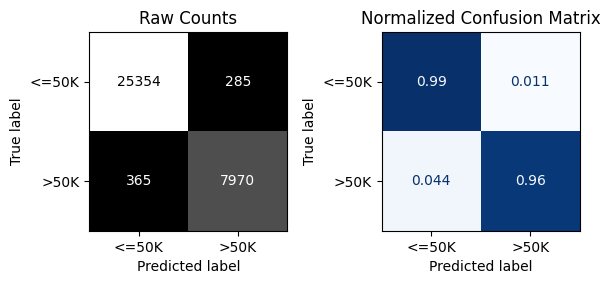


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

       <=50K       0.87      0.91      0.89      6381
        >50K       0.68      0.58      0.63      2113

    accuracy                           0.83      8494
   macro avg       0.77      0.74      0.76      8494
weighted avg       0.82      0.83      0.82      8494



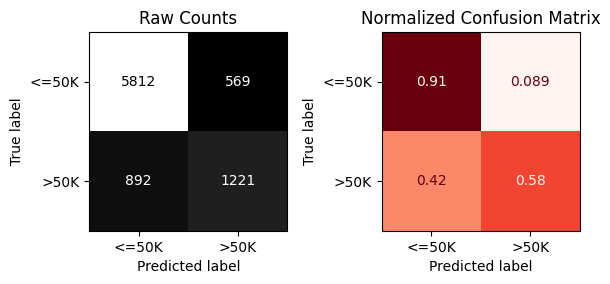

In [25]:
# Evaluate the Model
evaluate_classification(model_pipe, X_train, y_train, X_test, y_test,figsize=(6,8))

In [26]:
#Extract and visualize the top 10 features using permutation importance
r = permutation_importance(model_pipe, X_test, y_test,n_repeats =5, random_state = 42)
r.keys()

dict_keys(['importances_mean', 'importances_std', 'importances'])

In [27]:
## can make the mean importances into a series
permutation_importances = pd.Series(r['importances_mean'],index=X_test.columns,
                           name = 'permutation importance')
permutation_importances = permutation_importances.sort_values(ascending=False)
permutation_importances.head(10)

,permutation importance
capital-gain,0.043513
capital-loss,0.008665
marital-status,0.008406
educational-num,0.002284
native-country,-0.000235
relationship,-0.001483
workclass,-0.002284
gender,-0.002519
race,-0.002896
occupation,-0.005628


In [28]:
def plot_importance_color_ax(importances, top_n=None,  figsize=(8,6), color_dict=None, ax=None):
# sorting with asc=false for correct order of bars
   if top_n==None:
       ## sort all features and set title
       plot_vals = importances.sort_values()
       title = "All Features - Ranked by Importance"
   else:
       ## sort features and keep top_n and set title
       plot_vals = importances.sort_values().tail(top_n)
       title = f"Top {top_n} Most Important Features"
   ## create plot with colors, if provided
   if color_dict is not None:
       ## Getting color list and saving to plot_kws
       colors = plot_vals.index.map(color_dict)
       ax = plot_vals.plot(kind='barh', figsize=figsize, color=colors, ax=ax)
   else:
## create plot without colors, if not provided
       ax = plot_vals.plot(kind='barh', figsize=figsize, ax=ax)
# set titles and axis labels
   ax.set(xlabel='Importance',ylabel='Feature Names',title=title)
 ## return ax in case want to continue to update/modify figure
   return ax# sorting with asc=false for correct order of bars
   if top_n==None:
       ## sort all features and set title
       plot_vals = importances.sort_values()
       title = "All Features - Ranked by Importance"
   else:
       ## sort features and keep top_n and set title
       plot_vals = importances.sort_values().tail(top_n)
       title = f"Top {top_n} Most Important Features"
   ## create plot with colors, if provided
   if color_dict is not None:
       ## Getting color list and saving to plot_kws
       colors = plot_vals.index.map(color_dict)
       ax = plot_vals.plot(kind='barh', figsize=figsize, color=colors, ax=ax)
   else:
## create plot without colors, if not provided
       ax = plot_vals.plot(kind='barh', figsize=figsize, ax=ax)
# set titles and axis labels
   ax.set(xlabel='Importance',ylabel='Feature Names',title=title)
 ## return ax in case want to continue to update/modify figure
   return ax

<Axes: title={'center': 'Top 10 Most Important Features'}, xlabel='Importance', ylabel='Feature Names'>

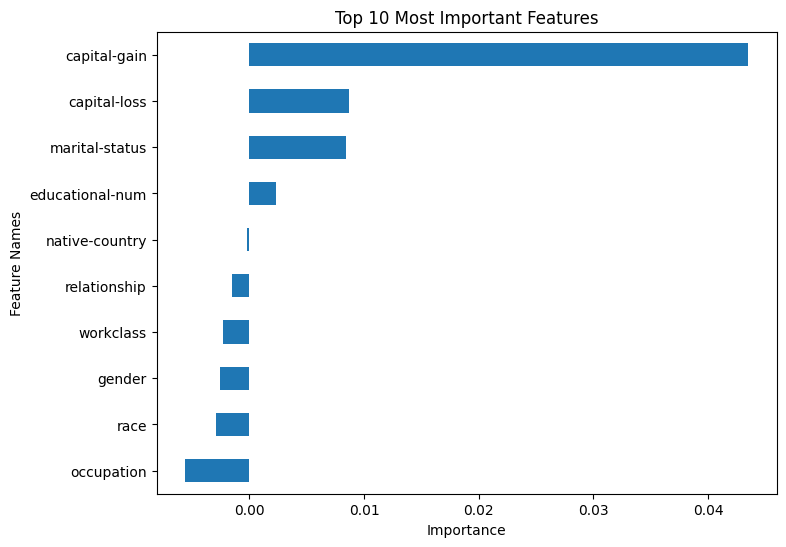

In [29]:
# Visualize top 10 features
plot_importance_color_ax(permutation_importances, top_n=10)


#### Do these features make sense based on the business case?


 - Yes, these features absolutely make sense.
 - The feature importance results are economically logical: capital-gain is the strongest predictor since investment income strongly correlates with earning above 50K, followed by capital-loss, which also signals financial activity. Marital-status matters because married individuals are more likely to have higher incomes, and educational-num is important as higher education generally leads to higher earning potential.



###Create Explanatory Visualizations for the most important features.


In [30]:
def plot_importance(importances, top_n=None,  figsize=(8,6)):
   # sorting with asc=false for correct order of bars
   if top_n==None:
# sort all features and set title
       plot_vals = importances.sort_values()
       title = "All Features - Ranked by Importance"
   else:
## sort features and keep top_n and set title
       plot_vals = importances.sort_values().tail(top_n)
       title = f"Top {top_n} Most Important Features"
   ## plotting top N importances
   ax = plot_vals.plot(kind='barh', figsize=figsize)
   ax.set(xlabel='Importance',
           ylabel='Feature Names',
           title=title)
   ## return ax in case want to continue to update/modify figur
   return ax

/tmp/ipykernel_270/1969441068.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/tmp/ipykernel_270/1969441068.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


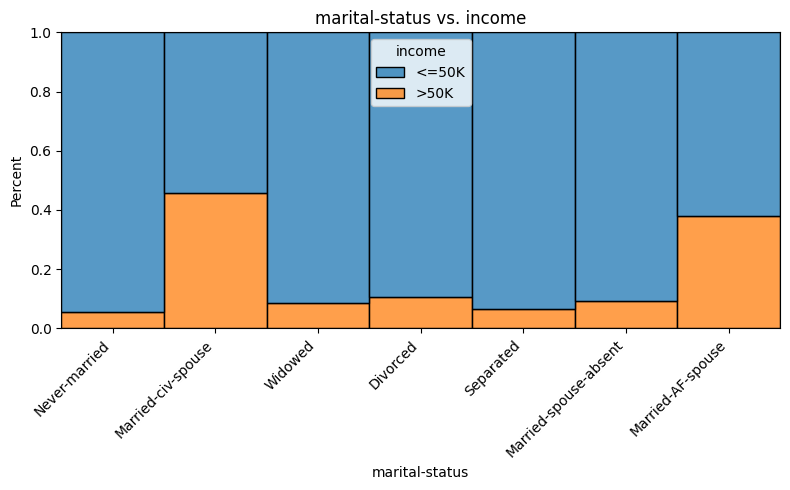

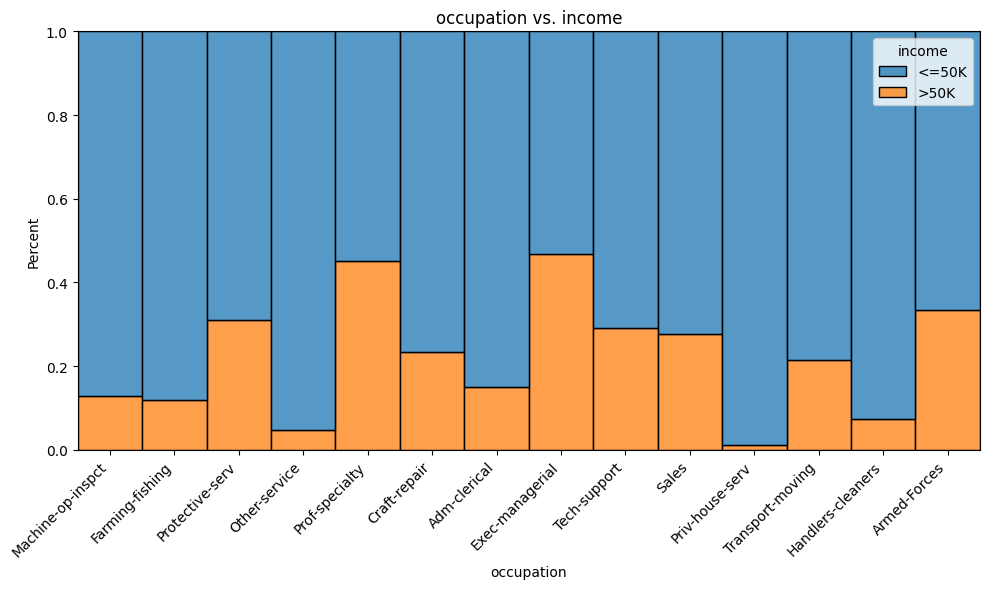

In [31]:
# Visualizing the relationship between important categorical features and income

# Marital Status vs. Income
plot_categorical_vs_target(df, x="marital-status", y="income", fillna=False, figsize=(8, 5), target_type="class");

# Occupation vs. Income
plot_categorical_vs_target(df, x="occupation", y="income", fillna=False, figsize=(10, 6), target_type="class");

plt.tight_layout()
plt.show()

- The first graph visualze the relationship between the target and the marital status, the graph shows that married individuales have a much higher probability of earning >50K compared to others.

- The second graph visualize the relationship betweeen the target and the occupation, it shows that certain occupations such as Exec-managerial, Prof-specialty, Protective-serv, Armed-Forces have more income than the other jobs. The reason some occupations may have higer income than others is becaues they requier higher education, specialized skills, leadership roles so higher salaries are expected. whereas the remaining jobs might be manual labor, entry-level, lower skill requirements.

## Feature Engineering

In [32]:
# Combine capital gain/loss to create total_capital,
X_train["capital_total"] = X_train["capital-gain"] - X_train["capital-loss"]
X_test["capital_total"] = X_test["capital-gain"] - X_test["capital-loss"]

In [33]:
# Combine Relationship and marital-status to create Family_role
X_train["family_role"]=X_train["relationship"] + X_train["marital-status"]
X_test["family_role"]=X_test["relationship"] + X_test["marital-status"]

In [34]:
# Combine hours-per-week and educational-num to create work_intensity -This captures education productivity.
X_train["work_intensity"] = X_train["hours-per-week"] * X_train["educational-num"]
X_test["work_intensity"] = X_test["hours-per-week"] * X_test["educational-num"]


In [35]:
#Drop features combined in new columns
X_train=X_train.drop(['capital-gain','capital-loss','relationship','marital-status',"educational-num","hours-per-week"],axis=1)
X_test=X_test.drop(['capital-gain','capital-loss','relationship','marital-status',"educational-num","hours-per-week"],axis=1)
X_train

,age,workclass,education,occupation,race,gender,native-country,capital_total,family_role,work_intensity
13809,34,Federal-gov,12th,Craft-repair,White,Male,United-States,0,HusbandMarried-civ-spouse,320
13317,38,Private,10th,Transport-moving,White,Male,United-States,3103,HusbandMarried-civ-spouse,240
21550,59,Private,9th,Transport-moving,White,Male,United-States,0,HusbandMarried-civ-spouse,300
24555,56,Private,HS-grad,Other-service,Black,Female,Jamaica,0,UnmarriedDivorced,360
41339,27,Private,Bachelors,Prof-specialty,White,Female,United-States,0,Own-childNever-married,520
...,...,...,...,...,...,...,...,...,...,...
6446,50,Self-emp-inc,Masters,Exec-managerial,White,Male,United-States,0,HusbandMarried-civ-spouse,700
11855,43,Self-emp-inc,Bachelors,Exec-managerial,White,Male,United-States,0,HusbandMarried-civ-spouse,520
43465,23,Private,Some-college,Other-service,White,Female,United-States,0,Other-relativeNever-married,400
863,33,Local-gov,9th,Other-service,White,Male,United-States,0,HusbandMarried-civ-spouse,200


In [36]:
# Define the tuple for categorical columns
cat_col_fe=X_train.select_dtypes(include='object').columns
#impute missing values
cat_imputer_fe=SimpleImputer(strategy="constant", fill_value="MISSING")
# one hot encoding the data
col_ohe_fe=OneHotEncoder(handle_unknown="ignore", sparse_output=False)
# make pipeline
cat_pipeline_fe=make_pipeline(cat_imputer_fe,col_ohe_fe)
# Make a tuple
cat_tuple_fe=("categorical",cat_pipeline_fe,cat_col_fe)

In [37]:
# Define the tuple for numerical columns
num_col_fe=X_train.select_dtypes(include='number').columns
#impute missing values
num_imputer_fe=SimpleImputer(strategy="median")
# scale
num_scaler_fe=StandardScaler()
# make pipeline
num_pipeline_fe=make_pipeline(num_imputer_fe,num_scaler_fe)
# Make a tuple
num_tuple_fe=("numerical",num_pipeline_fe,num_col_fe)

In [38]:
# Make a column transformer
preprocesser_fe=ColumnTransformer([cat_tuple_fe,num_tuple_fe],remainder="passthrough")
X_train_fe=preprocesser_fe.fit_transform(X_train)
X_test_fe=preprocesser_fe.transform(X_test)

In [39]:
# Initaite the random forest classifier after features selection
model_fe=RandomForestClassifier(n_estimators=200,class_weight='balanced',random_state=42)
#Create a pippeline
model_fe_pipe=make_pipeline(preprocesser_fe,model)
# fit and transform the model on training data
model_fe_pipe.fit(X_train,y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('categorical',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(fill_value='MISSING',
                                                                                 strategy='constant')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  Index(['workclass', 'education', 'occupation', 'race', 'gender',
       'native-country', 'family_role'],
      dtype='object')),
                                                 ('numerical',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  Index(['age', 'capital_total', 'work_intensity'], dtype='object'))])),
                ('randomforestclassifier',
                 RandomForestClassifier(random_state=42))])

----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

       <=50K       0.99      0.99      0.99     25639
        >50K       0.97      0.96      0.96      8335

    accuracy                           0.98     33974
   macro avg       0.98      0.97      0.97     33974
weighted avg       0.98      0.98      0.98     33974



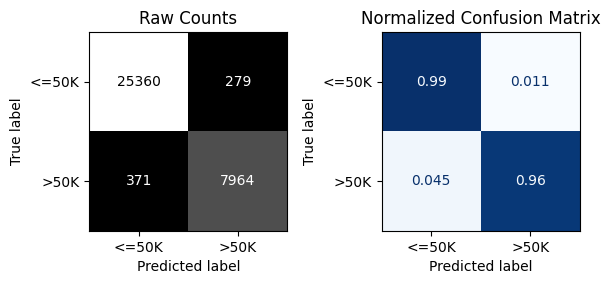


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

       <=50K       0.87      0.91      0.89      6381
        >50K       0.68      0.57      0.62      2113

    accuracy                           0.83      8494
   macro avg       0.77      0.74      0.75      8494
weighted avg       0.82      0.83      0.82      8494



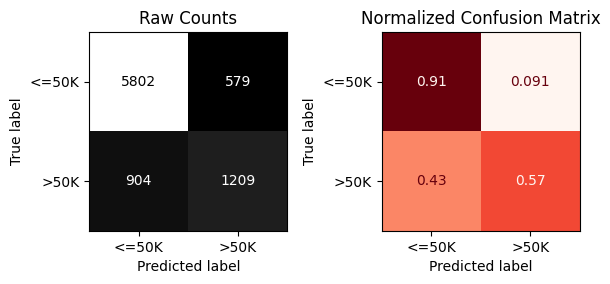

In [40]:
# Evaluate the Model
evaluate_classification(model_fe_pipe, X_train, y_train, X_test, y_test,figsize=(6,8))

### Embaded Features

In [41]:
# Instantiate a lostistic regression model
log_reg = LogisticRegression(C=1e12)
# Define the selector object using the model. Use default threshold (mean)
selector = SelectFromModel(log_reg)
# Fit the selector on the training data
selector.fit(X_train_fe,y_train)
selector

SelectFromModel(estimator=LogisticRegression(C=1000000000000.0))

In [42]:
# .get_support returns an array of T/F whether it is above threshold
above_threshold = selector.get_support()
# Only include the features that are above the threshold in X train and X test
X_train_sel = X_train_fe[:, above_threshold]
X_test_sel = X_test_fe[:, above_threshold]
X_train_sel.shape

(33974, 47)

----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

       <=50K       0.95      0.79      0.86     25639
        >50K       0.57      0.88      0.69      8335

    accuracy                           0.81     33974
   macro avg       0.76      0.83      0.78     33974
weighted avg       0.86      0.81      0.82     33974



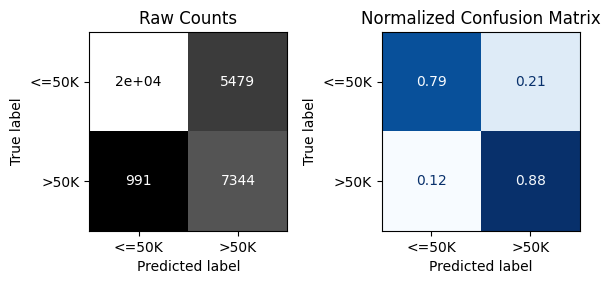


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

       <=50K       0.94      0.78      0.85      6381
        >50K       0.56      0.85      0.68      2113

    accuracy                           0.80      8494
   macro avg       0.75      0.82      0.77      8494
weighted avg       0.85      0.80      0.81      8494



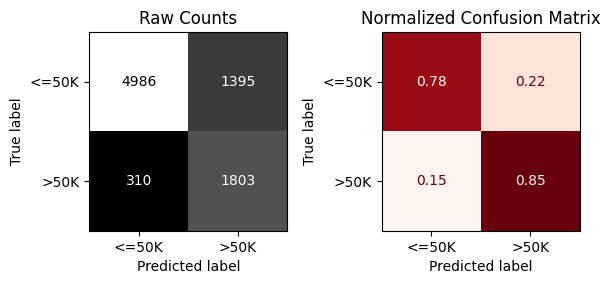

In [43]:
# Instantiate random forest Classifier after embadding features.
rf = RandomForestClassifier(n_estimators=200,class_weight='balanced',random_state=42)
rf.fit(X_train_sel, y_train)
evaluate_classification(rf, X_train_sel, y_train, X_test_sel, y_test)

#### Tuining the Random forest Model after embadding the features

In [44]:
#Define the parameters to GridSearch
param_grid = {'n_estimators': [200,300],'max_depth': [10,20,None],'min_samples_split': [2,5],'min_samples_leaf': [1,3],'max_features': ['sqrt','log2']}

In [45]:
#Define the Grid
grid = GridSearchCV(rf,param_grid,cv=5,scoring='f1',n_jobs=-1)
# Fit the GridSearch
grid.fit(X_train_sel,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(


GridSearchCV(cv=5,
             estimator=RandomForestClassifier(class_weight='balanced',
                                              n_estimators=200,
                                              random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [10, 20, None],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_leaf': [1, 3],
                         'min_samples_split': [2, 5],
                         'n_estimators': [200, 300]},
             scoring='f1')

In [46]:
best_rf = grid.best_estimator_
best_rf



RandomForestClassifier(class_weight='balanced', max_depth=10, n_estimators=200,
                       random_state=42)

----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

       <=50K       0.95      0.79      0.86     25639
        >50K       0.57      0.88      0.69      8335

    accuracy                           0.81     33974
   macro avg       0.76      0.83      0.78     33974
weighted avg       0.86      0.81      0.82     33974



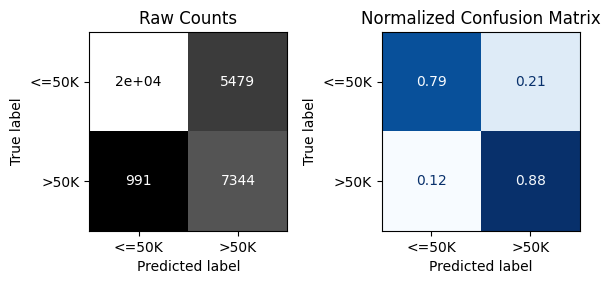


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

       <=50K       0.94      0.78      0.85      6381
        >50K       0.56      0.85      0.68      2113

    accuracy                           0.80      8494
   macro avg       0.75      0.82      0.77      8494
weighted avg       0.85      0.80      0.81      8494



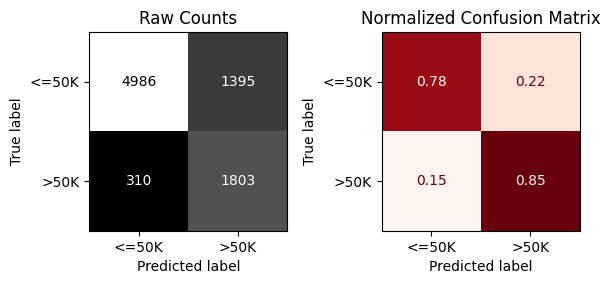

In [47]:
evaluate_classification(rf, X_train_sel, y_train, X_test_sel, y_test)

In [48]:
# Get all feature names from the preprocessor
all_features = preprocesser_fe.get_feature_names_out()

# Filter them using the selector's mask
selected_features = all_features[selector.get_support()]

print(f"Number of selected features: {len(selected_features)}")
print("Top 10 selected features:")
print(selected_features[:10])

Number of selected features: 47
Top 10 selected features:
['categorical__workclass_Without-pay' 'categorical__education_10th'
 'categorical__education_1st-4th' 'categorical__education_7th-8th'
 'categorical__education_Doctorate' 'categorical__education_Masters'
 'categorical__education_Preschool' 'categorical__education_Prof-school'
 'categorical__occupation_Exec-managerial'
 'categorical__occupation_Farming-fishing']


In [55]:
r_rf = permutation_importance(rf, X_test_sel, y_test,n_repeats =5, random_state = 42)
permutation_importances_rf = pd.Series(r_rf['importances_mean'],index=selected_features,name='permutation importance')

permutation_importances_rf = permutation_importances_rf.sort_values(ascending=False)
permutation_importances_rf.head(10)

NameError: name 'imp' is not defined

In [ ]:
# Visualize top 10 features
plot_importance_color_ax(permutation_importances_rf, top_n=10)

- Comparing the two models shows that capital-related features remain the strongest predictors of income. In the default model, capital-gain and capital-loss were the most influential variables, while after feature engineering they were combined into capital_total, which became the most important feature in the optimized model.
- The optimized model also highlights the importance of family role, marital status, occupation, and education-related categories, indicating that household structure, job type, and educational background play key roles in predicting income level.
-  Overall, feature engineering, feature selection, and hyperparameter tuning helped the model focus on more meaningful predictors while maintaining stable performance without overfitting.

## Build a Neural Network Model

In [52]:
#Check the Input Shape
input_shape=X_train_sel.shape[1]
input_shape

47

In [77]:
# Encode target variable for neural network
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train)
y_test = label_encoder.transform(y_test)

In [78]:
#Build the neural Network structure:
def build_model():
 model = Sequential()

# Hidden Layer
 model.add(Dense(32, activation='relu', input_dim=input_shape))

# Output Layer (Binary Classification)
 model.add(Dense(1, activation='sigmoid'))

 # Use the directly imported Precision and Recall classes
 model.compile(loss = 'bce', optimizer = 'adam', metrics=['accuracy', Precision(), Recall()])
 return model

In [79]:
# Call our build function to build model
clf_model = build_model()
# Get model summary
clf_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 32)             │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,569 (6.13 KB)

 Trainable params: 1,569 (6.13 KB)

 Non-trainable params: 0 (0.00 B)

In [80]:
# Add Early Stopping step
early_stop = EarlyStopping(monitor='val_accuracy', patience=5,restore_best_weights=True)
# Save the history
history = clf_model.fit(X_train_sel,y_train,epochs=50,validation_split=0.2,batch_size=32,callbacks=[early_stop],verbose=1)

Epoch 1/50
850/850 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7817 - loss: 0.4800 - precision_3: 0.6463 - recall_3: 0.2972 - val_accuracy: 0.8259 - val_loss: 0.3588 - val_precision_3: 0.7151 - val_recall_3: 0.4691
Epoch 2/50
850/850 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8236 - loss: 0.3641 - precision_3: 0.7166 - recall_3: 0.4560 - val_accuracy: 0.8286 - val_loss: 0.3545 - val_precision_3: 0.7272 - val_recall_3: 0.4691
Epoch 3/50
850/850 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8266 - loss: 0.3575 - precision_3: 0.7272 - recall_3: 0.4620 - val_accuracy: 0.8293 - val_loss: 0.3517 - val_precision_3: 0.7259 - val_recall_3: 0.4757
Epoch 4/50
850/850 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8315 - loss: 0.3515 - precision_3: 0.7376 - recall_3: 0.4838 - val_accuracy: 0.8293 - val_loss: 0.3488 - val_precision_3: 0.7263 - val_recall_3: 0.4751
Epoch 5/50
850/850 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8249 - loss: 0.3578 - precision_3: 0.7223 - recall_3: 0.4725 -

In [81]:
# Custom function for plotting each metric
def plot_history(history, figsize=(6,12), marker='o'):

    # Get list of metrics from history
    metrics = [c for c in history.history if not c.startswith('val_')]

    ## Separate row for each metric
    fig, axes = plt.subplots(nrows=len(metrics),figsize=figsize)

    # For each metric
    for i, metric_name in enumerate(metrics):

        # Get the axis for the current metric
        ax = axes[i]

        # Get metric from history.history
        metric_values = history.history[metric_name]
        # Get epochs from history
        epochs = history.epoch

        # Plot the training metric
        ax.plot(epochs, metric_values, label=metric_name, marker=marker)

        ## Check if val_{metric} exists. if so, plot:
        val_metric_name = f"val_{metric_name}"
        if val_metric_name in history.history:
            # Get validation values and plot
            metric_values = history.history[val_metric_name]
            ax.plot(epochs,metric_values,label=val_metric_name, marker=marker)

        # Final subplot adjustments
        ax.legend()
        ax.set_title(metric_name)
    fig.tight_layout()

    return fig, axes

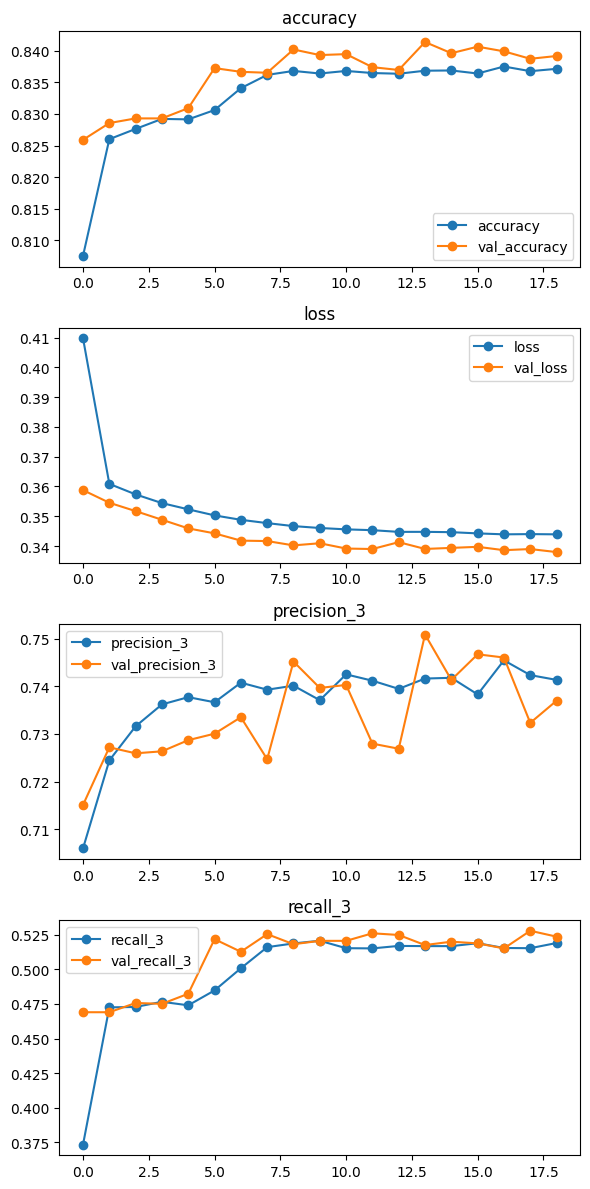

In [82]:
# plot learning history
plot_history(history);